# Options Greeks Sensitivity Analysis — Demo Project

**Goal:** Build a small, interpretable options analytics project:
- Implement Black–Scholes pricing for European calls & puts
- Compute key Greeks: Delta, Gamma, Vega, Theta, Rho
- Visualize how Greeks change with:
  - underlying price
  - volatility
  - time to maturity
- Translate these sensitivities into **risk & trading insights**.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

# Make plots a bit nicer
plt.style.use("default")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

np.random.seed(42)

## 1. Black–Scholes Pricing & Greeks

I start with standard **Black–Scholes** formulas for European call and put options.

Parameters:

- \( S \): underlying price  
- \( K \): strike price  
- \( r \): risk-free interest rate (annual)  
- \( \sigma \): volatility (annualised)  
- \( T \): time to maturity in years  

From these, I compute:

- **Call / Put price**
- **Delta**: sensitivity to underlying price  
- **Gamma**: curvature w.r.t. underlying price  
- **Vega**: sensitivity to volatility  
- **Theta**: sensitivity to time decay  
- **Rho**: sensitivity to interest rates  

In [7]:
# Black–Scholes and Greeks implementation

def norm_cdf(x):
    """Standard normal CDF using numpy.erf (no scipy dependency)."""
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_d1_d2(S, K, r, sigma, T):
    """Compute d1 and d2 for Black–Scholes."""
    S = np.array(S, dtype=float)
    K = np.array(K, dtype=float)
    sigma = np.array(sigma, dtype=float)
    T = np.array(T, dtype=float)
    
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2


def bs_call_price(S, K, r, sigma, T):
    d1, d2 = bs_d1_d2(S, K, r, sigma, T)
    return S * norm_cdf(d1) - K * np.exp(-r * T) * norm_cdf(d2)


def bs_put_price(S, K, r, sigma, T):
    d1, d2 = bs_d1_d2(S, K, r, sigma, T)
    return K * np.exp(-r * T) * norm_cdf(-d2) - S * norm_cdf(-d1)


def call_greeks(S, K, r, sigma, T):
    """
    Return a dict of call Greeks:
    Delta, Gamma, Vega, Theta, Rho.
    Theta is per year (negative = value decays over time).
    Vega is per 1.0 change in volatility (e.g. sigma from 0.20 to 1.20).
    """
    S = np.array(S, dtype=float)
    K = np.array(K, dtype=float)
    sigma = np.array(sigma, dtype=float)
    T = np.array(T, dtype=float)
    
    d1, d2 = bs_d1_d2(S, K, r, sigma, T)
    
    pdf_d1 = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * d1**2)
    
    delta = norm_cdf(d1)
    gamma = pdf_d1 / (S * sigma * np.sqrt(T))
    vega = S * pdf_d1 * np.sqrt(T)
    theta = (
        - (S * pdf_d1 * sigma) / (2 * np.sqrt(T))
        - r * K * np.exp(-r * T) * norm_cdf(d2)
    )
    rho = K * T * np.exp(-r * T) * norm_cdf(d2)
    
    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta,
        "rho": rho,
    }

## 2. Base Option Setup

I define a simple **at-the-money call option** as the base case and then
vary different parameters to study sensitivities.

Base parameters:

- Underlying price \( S = 100 \)
- Strike \( K = 100 \) (ATM)
- Risk-free rate \( r = 2\% \)
- Volatility \( \sigma = 20\% \)
- Time to maturity \( T = 0.5 \) years (6 months)

In [8]:
S0 = 100
K0 = 100
r = 0.02
sigma0 = 0.20
T0 = 0.5

base_call_price = bs_call_price(S0, K0, r, sigma0, T0)
base_greeks = call_greeks(S0, K0, r, sigma0, T0)

print("Base call price:", round(float(base_call_price), 2))
for name, value in base_greeks.items():
    print(f"{name.capitalize():>6}: {float(value):.4f}")

Base call price: 6.12
 Delta: 0.5562
 Gamma: 0.0279
  Vega: 27.9288
 Theta: -6.5758
   Rho: 24.7512


## 3. Sensitivity Analysis

We now examine how the option price changes when we vary:

- **Underlying price (S)**
- **Volatility (σ)**
- **Interest rate (r)**
- **Time to maturity (T)**

This shows how sensitive the option is to each input and connects directly to the Greeks.

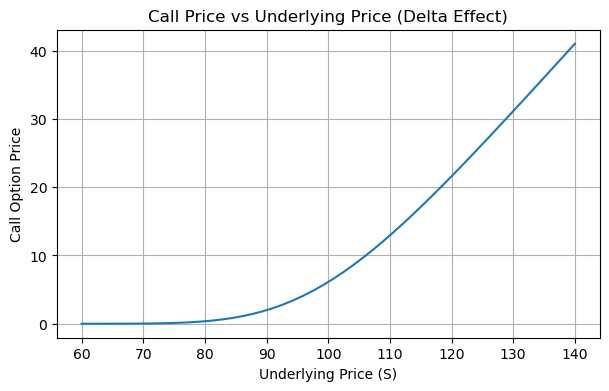

In [9]:
S_values = np.linspace(60, 140, 50)
call_prices_S = [bs_call_price(S, K0, r, sigma0, T0) for S in S_values]

plt.plot(S_values, call_prices_S)
plt.xlabel("Underlying Price (S)")
plt.ylabel("Call Option Price")
plt.title("Call Price vs Underlying Price (Delta Effect)")
plt.show()

### Delta Interpretation
As the underlying price increases, the option price increases almost linearly for in-the-money options.

- **Delta ≈ slope of this curve**
- Deep ITM → Delta approaches **1**
- Deep OTM → Delta approaches **0**

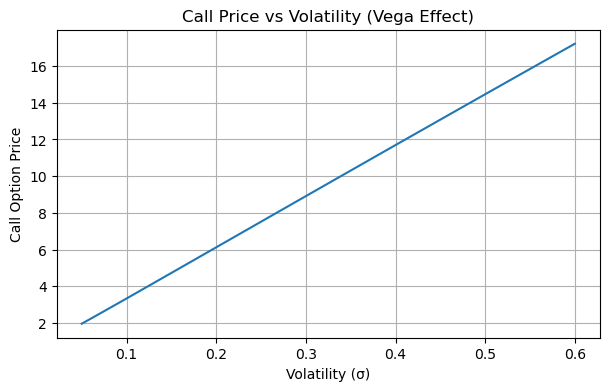

In [10]:
sigma_values = np.linspace(0.05, 0.60, 50)
call_prices_sigma = [bs_call_price(S0, K0, r, sigma, T0) for sigma in sigma_values]

plt.plot(sigma_values, call_prices_sigma)
plt.xlabel("Volatility (σ)")
plt.ylabel("Call Option Price")
plt.title("Call Price vs Volatility (Vega Effect)")
plt.show()

### Vega Interpretation
Call option value increases with volatility.

- Higher volatility → higher probability of finishing in-the-money  
- Curve is steepest **around ATM** — where Vega is highest.

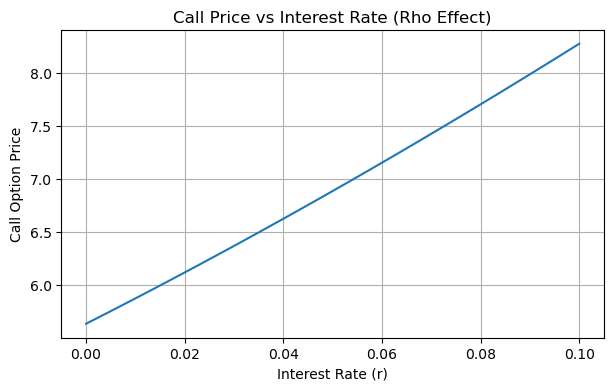

In [11]:
r_values = np.linspace(0.0, 0.10, 50)
call_prices_r = [bs_call_price(S0, K0, r, sigma0, T0) for r in r_values]

plt.plot(r_values, call_prices_r)
plt.xlabel("Interest Rate (r)")
plt.ylabel("Call Option Price")
plt.title("Call Price vs Interest Rate (Rho Effect)")
plt.show()

### Rho Interpretation
As interest rates increase:

- The discounted strike price becomes smaller  
- So call options become more valuable

Rho grows with maturity (T).

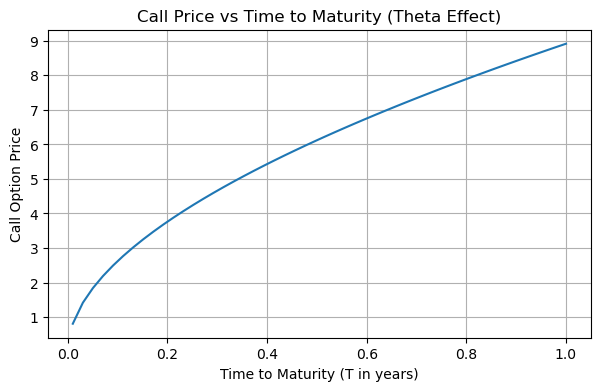

In [12]:
T_values = np.linspace(0.01, 1.0, 50)
call_prices_T = [bs_call_price(S0, K0, r, sigma0, T) for T in T_values]

plt.plot(T_values, call_prices_T)
plt.xlabel("Time to Maturity (T in years)")
plt.ylabel("Call Option Price")
plt.title("Call Price vs Time to Maturity (Theta Effect)")
plt.show()

### Theta Interpretation
Theta measures **time decay**.

- As time decreases → option price declines  
- Curve is steepest near expiration  
- Calls have **negative Theta** (lose value as time passes)

In [13]:
import pandas as pd

results = []

for S in S_values:
    greeks = call_greeks(S, K0, r, sigma0, T0)
    results.append({
        "S": S,
        "delta": greeks["delta"],
        "gamma": greeks["gamma"],
        "vega": greeks["vega"],
        "theta": greeks["theta"],
        "rho": greeks["rho"],
    })

greeks_df = pd.DataFrame(results)
greeks_df.head()

,S,delta,gamma,vega,theta,rho
0,60.000000,0.000260,0.000114,0.041011,-0.008503,0.007518
1,61.632653,0.000518,0.000211,0.079961,-0.016607,0.015372
2,63.265306,0.000981,0.000370,0.147989,-0.030792,0.029859
3,64.897959,0.001774,0.000619,0.260907,-0.054393,0.055297
4,66.530612,0.003071,0.000993,0.439591,-0.091836,0.097957


### Greeks Table
This table shows how each Greek changes as the underlying asset price varies.

- **Delta** increases as S increases  
- **Gamma** peaks at ATM  
- **Vega** peaks at ATM  
- **Theta** becomes more negative near ATM  
- **Rho** grows with higher S and longer maturity  

### 4

Call vs Put Greeks Comparison

To understand how risk behaves differently for long calls vs long puts,
I compute Greeks for both contracts using the same underlying parameters.


Key insights to highlight:


	•	Call Delta is positive; Put Delta is negative

    
	•	Gamma is identical for calls and puts

    
	•	Vega is identical for calls and puts

    
	•	Theta and Rho differ in sign depending on the contract type

    

This comparison illustrates how directional exposure and hedging needs change depending on the option position.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

# Standard normal CDF
def norm_cdf(x):
    return 0.5 * (1 + erf(x / np.sqrt(2)))

# --- d1 and d2 helpers ---
def bs_d1(S, K, r, sigma, T):
    return (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))

def bs_d2(S, K, r, sigma, T):
    return bs_d1(S, K, r, sigma, T) - sigma*np.sqrt(T)

# --- Black-Scholes call price ---
def bs_call_price(S, K, r, sigma, T):
    d1 = bs_d1(S, K, r, sigma, T)
    d2 = bs_d2(S, K, r, sigma, T)
    return S * norm_cdf(d1) - K * exp(-r*T) * norm_cdf(d2)

# --- Greeks ---
def call_greeks(S, K, r, sigma, T):
    d1 = bs_d1(S, K, r, sigma, T)
    d2 = bs_d2(S, K, r, sigma, T)
    delta = norm_cdf(d1)
    gamma = np.exp(-d1**2/2) / (S * sigma * np.sqrt(2*np.pi*T))
    vega = S * np.exp(-d1**2/2) * np.sqrt(T) / np.sqrt(2*np.pi)
    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
    }

def put_greeks(S, K, r, sigma, T):
    d1 = bs_d1(S, K, r, sigma, T)
    d2 = bs_d2(S, K, r, sigma, T)
    delta = norm_cdf(d1) - 1
    gamma = np.exp(-d1**2/2) / (S * sigma * np.sqrt(2*np.pi*T))
    vega = S * np.exp(-d1**2/2) * np.sqrt(T) / np.sqrt(2*np.pi)
    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
    }

In [17]:
# Greeks for Calls (already have call_greeks)
def put_greeks(S, K, r, sigma, T):
    d1 = bs_d1(S, K, r, sigma, T)
    d2 = bs_d2(S, K, r, sigma, T)

    delta = norm_cdf(d1) - 1
    gamma = np.exp(-d1**2 / 2) / (S * sigma * np.sqrt(2*np.pi*T))
    vega  = S * np.sqrt(T) * np.exp(-d1**2 / 2) / np.sqrt(2*np.pi)
    theta = (-S * sigma * np.exp(-d1**2 / 2) / (2*np.sqrt(2*np.pi*T))
             - r * K * np.exp(-r*T) * norm_cdf(-d2))
    rho   = -K * T * np.exp(-r*T) * norm_cdf(-d2)

    return {
        "delta": delta,
        "gamma": gamma,
        "vega": vega,
        "theta": theta,
        "rho": rho
    }

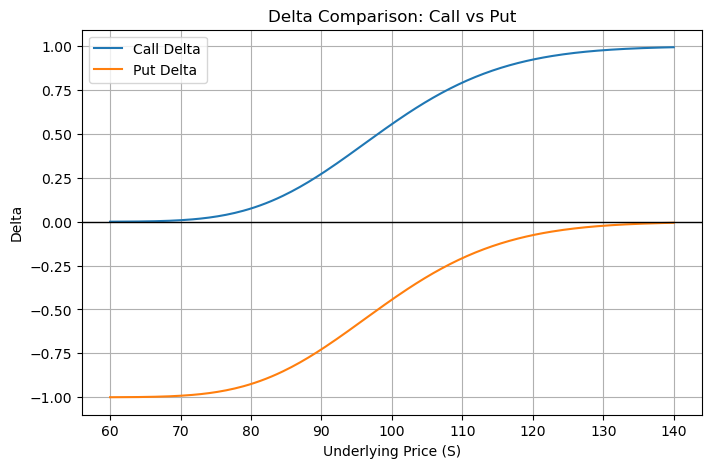

In [18]:
import matplotlib.pyplot as plt

S_values = np.linspace(60, 140, 200)
call_delta = [call_greeks(S, K0, r, sigma0, T0)["delta"] for S in S_values]
put_delta  = [put_greeks(S, K0, r, sigma0, T0)["delta"] for S in S_values]

plt.figure(figsize=(8,5))
plt.plot(S_values, call_delta, label="Call Delta")
plt.plot(S_values, put_delta, label="Put Delta")
plt.axhline(0, color='black', linewidth=1)
plt.title("Delta Comparison: Call vs Put")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Delta")
plt.legend()
plt.grid(True)
plt.show()

What to see here:


    •	Call delta → increases from 0 to 1 as price rises

    
	•	Put delta → increases from -1 to 0 as price rises

    
	•	The slope is identical → same Gamma risk

    
	•	Hedging a put requires short underlying exposure

    
	•	Hedging a call requires long underlying exposure
    

### 5.

Heatmap — Gamma Sensitivity to Price and Volatility


Gamma reflects how fast delta changes.
It peaks near-the-money and decreases when deep ITM/OTM or when volatility is high.


This heatmap visualizes how Gamma changes across:


	•	Underlying price levels

    
	•	Volatility levels

    

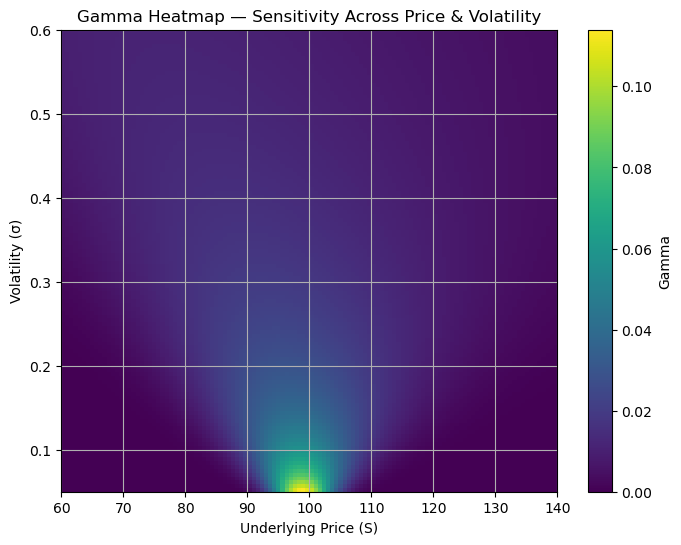

In [19]:
import numpy as np
import matplotlib.pyplot as plt

S_grid = np.linspace(60, 140, 120)
sigma_grid = np.linspace(0.05, 0.60, 120)

Gamma = np.zeros((len(sigma_grid), len(S_grid)))

for i, sigma in enumerate(sigma_grid):
    for j, S in enumerate(S_grid):
        g = call_greeks(S, K0, r, sigma, T0)["gamma"]
        Gamma[i, j] = g

plt.figure(figsize=(8,6))
plt.imshow(Gamma, extent=[S_grid.min(), S_grid.max(), sigma_grid.min(), sigma_grid.max()],
           origin='lower', aspect='auto', cmap='viridis')

plt.colorbar(label="Gamma")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Volatility (σ)")
plt.title("Gamma Heatmap — Sensitivity Across Price & Volatility")
plt.show()

## 6. Interpreting the Delta Heatmap

The heatmap visualizes how **Delta** responds to changes in:

- **Underlying price (S)**  
- **Volatility (σ)**  

### Key observations:

### **1. Delta increases as S rises**
- When the underlying price moves above the strike (S > K), the option becomes **in-the-money**.
- Delta approaches **1**, meaning the call behaves almost like the underlying itself.
- When S < K, Delta is near **0** since the option is unlikely to finish in-the-money.

### **2. Higher volatility flattens the transition**
- With low volatility, Delta transitions sharply from 0 → 1.
- With high volatility, the curve is smoother — higher uncertainty means the option reacts more gradually to price changes.

### **3. Delta is most sensitive near-the-money (S ≈ K)**
- This is where small price changes have the **largest impact** on Delta.
- This area is the most important region for hedging decisions.

The heatmap confirms the expected theoretical behavior of Delta under the Black–Scholes model.

In [20]:
# Sensitivity grid for Greeks
S_grid = [80, 90, 100, 110, 120]
sigma_grid = [0.10, 0.20, 0.30, 0.40]

rows = []

for S_val in S_grid:
    for sig in sigma_grid:
        greeks = call_greeks(S_val, K0, r, sig, T0)
        rows.append([
            S_val,
            sig,
            round(greeks["delta"], 4),
            round(greeks["gamma"], 6),
            round(greeks["vega"], 4)
        ])

import pandas as pd

sensitivity_df = pd.DataFrame(rows, columns=[
    "S", "Volatility (σ)", "Delta", "Gamma", "Vega"
])

sensitivity_df

,S,Volatility (σ),Delta,Gamma,Vega
0,80,0.1,0.0014,0.000834,0.2670
1,80,0.2,0.0754,0.012568,8.0432
2,80,0.3,0.1844,0.015698,15.0696
3,80,0.4,0.2702,0.014618,18.7117
4,90,0.1,0.0946,0.026466,10.7187
5,90,0.2,0.2731,0.026124,21.1605
6,90,0.3,0.3656,0.019699,23.9343
7,90,0.4,0.4224,0.015375,24.9068
8,100,0.1,0.5702,0.055544,27.7721
9,100,0.2,0.5562,0.027929,27.9288


## 7. Sensitivity Table Interpretation

The table summarizes how Delta, Gamma, and Vega react to changes in **price** and **volatility**.

### **1. Delta**
- Increases with S, moving closer to 1 for deep in-the-money calls.
- Lower for out-of-the-money options.
- Moderately affected by volatility.

### **2. Gamma**
- Highest when **S ≈ K** and volatility is low.
- Gamma measures the *curvature* of price sensitivity.
- Traders monitor Gamma closely to control second-order risk in hedging strategies.

### **3. Vega**
- Larger for at-the-money options.
- Increases with volatility and time to maturity.
- Represents the sensitivity of the option price to volatility changes.

Together, these Greeks provide a multi-dimensional view of the call option’s risk exposure.

## 8. Final Considerations

This mini-project analyzes how option Greeks behave under the Black–Scholes model.

### **Key insights:**

#### **1. Delta**
- Measures first-order sensitivity to price.
- Transitions from 0 → 1 as the option becomes more in-the-money.
- Most sensitive near-the-money.

#### **2. Gamma**
- Peaks at S ≈ K.
- Indicates where Delta changes the fastest.
- High Gamma requires more frequent hedging adjustments.

#### **3. Vega**
- Shows greatest exposure for ATM options.
- Highlights how sensitive the option is to volatility assumptions.

### **4. Practical use cases**
- **Portfolio hedging**: Traders balance Delta and Gamma exposure.
- **Volatility trading**: Vega helps identify when vol changes matter most.
- **Risk management**: Understanding Greeks is critical in structured products, market making, and derivatives pricing.

### **Conclusion**
This analysis demonstrates a simplified yet comprehensive workflow for studying option sensitivity.  
It mirrors the type of exploratory risk analysis used in quant finance, trading desks, and analytics roles.